In [ ]:
# Installation de LightGlue
!pip install git+https://github.com/cvg/LightGlue.git
!pip install torch torchvision numpy opencv-python matplotlib scipy

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from lightglue import LightGlue, SuperPoint
from lightglue.utils import load_image, rbd
from lightglue.viz2d import plot_images, plot_matches
from google.colab import files

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Environnement prêt sur : {device}")

  Cloning https://github.com/cvg/LightGlue.git to /tmp/pip-req-build-437hiio8
  Running command git clone --filter=blob:none --quiet https://github.com/cvg/LightGlue.git /tmp/pip-req-build-437hiio8
  Resolved https://github.com/cvg/LightGlue.git to commit 746fac2c042e05d1865315b1413419f1c1e7ba55
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 122.2 MB/s eta 0:00:00
  Created wheel for lightglue: filename=lightglue-0.0-py3-none-any.whl size=40026 sha256=80390216407a789da2bd9b9dfa4a91d3e273201b51bd4402e58490fd7bea0ba0
  Stored in directory: /tmp/pip-ephem-wheel-cache-ygl3wxjv/wheels/dc/16/88/ad4ddb490c3a6ff37eeface44b776cb588b19e169210e0fbf1
Successfully built lightglue
✅ Environnement prêt sur : cuda


In [ ]:
class SuperPointPruned(nn.Module):
    def __init__(self, scale=0.75):
        super().__init__()
        c1, c2, c3, c4 = int(64*scale), int(64*scale), int(128*scale), int(128*scale)

        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv1a = nn.Conv2d(1, c1, kernel_size=3, stride=1, padding=1)
        self.conv1b = nn.Conv2d(c1, c1, kernel_size=3, stride=1, padding=1)
        self.conv2a = nn.Conv2d(c1, c2, kernel_size=3, stride=1, padding=1)
        self.conv2b = nn.Conv2d(c2, c2, kernel_size=3, stride=1, padding=1)
        self.conv3a = nn.Conv2d(c2, c3, kernel_size=3, stride=1, padding=1)
        self.conv3b = nn.Conv2d(c3, c3, kernel_size=3, stride=1, padding=1)
        self.conv4a = nn.Conv2d(c3, c4, kernel_size=3, stride=1, padding=1)
        self.conv4b = nn.Conv2d(c4, c4, kernel_size=3, stride=1, padding=1)

        self.convPa = nn.Conv2d(c4, 256, kernel_size=3, stride=1, padding=1)
        self.convPb = nn.Conv2d(256, 65, kernel_size=1, stride=1, padding=0)
        self.convDa = nn.Conv2d(c4, 256, kernel_size=3, stride=1, padding=1)
        self.convDb = nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        x = self.relu(self.conv1a(x)); x = self.relu(self.conv1b(x)); x = self.pool(x)
        x = self.relu(self.conv2a(x)); x = self.relu(self.conv2b(x)); x = self.pool(x)
        x = self.relu(self.conv3a(x)); x = self.relu(self.conv3b(x)); x = self.pool(x)
        x = self.relu(self.conv4a(x)); feats = self.relu(self.conv4b(x))
        heatmap = self.convPb(self.relu(self.convPa(feats)))
        desc = self.convDb(self.relu(self.convDa(feats)))
        return heatmap, F.normalize(desc, p=2, dim=1)

print(" Architecture SuperPointPruned définie.")

✅ Architecture SuperPointPruned définie.


In [ ]:

print("Veuillez uploader 'superpoint_v075_refined.pth'...")
uploaded = files.upload()

# Initialisation des modèles
student_refined = SuperPointPruned(scale=0.75).to(device)
student_refined.load_state_dict(torch.load("superpoint_v075_refined.pth", map_location=device))
student_refined.eval()

# Le matcher LightGlue
matcher = LightGlue(features='superpoint').eval().to(device)

print("Modèles chargés et prêts.")

Veuillez uploader 'superpoint_v075_refined.pth'...


Saving superpoint_v075_refined.pth to superpoint_v075_refined (1).pth
✅ Modèles chargés et prêts.


In [ ]:
def extract_features_refined_v2(model, img_tensor):
    model.eval()
    with torch.no_grad():
        heatmap, desc = model(img_tensor)

    # 1. Extraction des probabilités
    prob = torch.softmax(heatmap, dim=1)[:, :-1]
    prob = prob.permute(0, 2, 3, 1).reshape(1, 30, 40, 8, 8)
    prob = prob.permute(0, 1, 3, 2, 4).reshape(1, 240, 320)

    # 2. On prend les N meilleurs points (Top-K) au lieu d'un seuil fixe
    N = 512
    flat_prob = prob.view(-1)
    top_k = torch.topk(flat_prob, k=N)

    # Coordonnées (y, x)
    indices = top_k.indices
    y = torch.div(indices, 320, rounding_mode='floor')
    x = indices % 320
    kpts = torch.stack([x, y], dim=1).float() # Format (N, 2)
    scores = top_k.values

    # 3. Interpolation des descripteurs (indispensable pour LightGlue)
    # Normalisation pour grid_sample : [0, W-1] -> [-1, 1]
    kpts_unit = kpts.clone()
    kpts_unit[:, 0] = (kpts_unit[:, 0] / (320 - 1)) * 2 - 1
    kpts_unit[:, 1] = (kpts_unit[:, 1] / (240 - 1)) * 2 - 1

    # Grid sample attend (B, C, H_out, W_out) avec coords (B, H_out, W_out, 2)
    grid_coords = kpts_unit.view(1, 1, N, 2)
    desc_sampled = F.grid_sample(desc, grid_coords, align_corners=True)
    desc_sampled = desc_sampled[0, :, 0, :].t() # (N, 256)
    desc_sampled = F.normalize(desc_sampled, p=2, dim=1)

    return {
        'keypoints': kpts[None],
        'scores': scores[None],
        'descriptors': desc_sampled[None],
        'image_size': torch.tensor([[320, 240]]).to(device)
    }

✅ Nombre de matches trouvés sur images réelles : 0


AssertionError: 

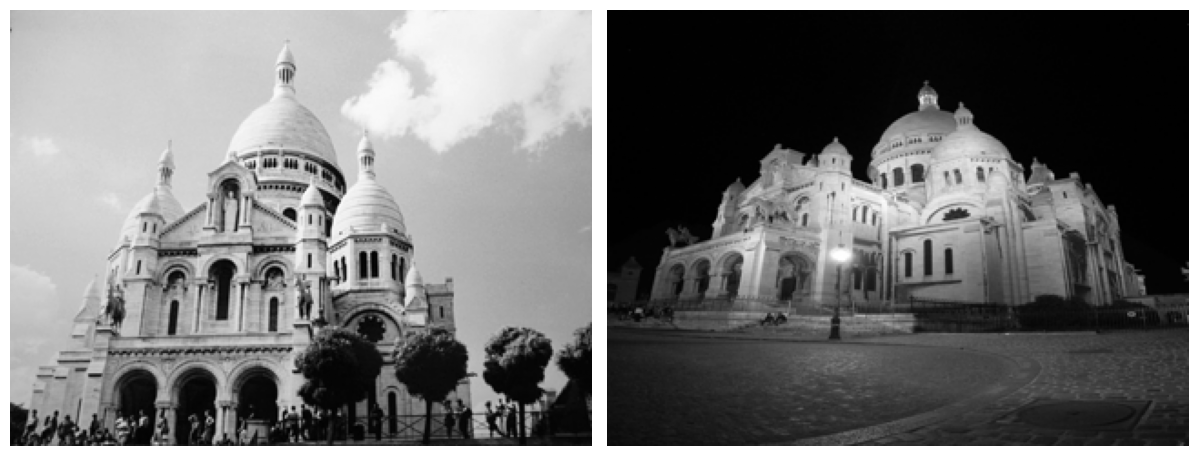

In [ ]:
import requests
from PIL import Image
from io import BytesIO

def download_and_preprocess(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('L') # Noir et blanc
    img = img.resize((320, 240)) # Taille attendue par ton modèle
    tensor = torch.from_numpy(np.array(img)).float()[None, None] / 255.0
    return tensor.to(device)

url1 = "https://raw.githubusercontent.com/cvg/LightGlue/main/assets/sacre_coeur1.jpg"
url2 = "https://raw.githubusercontent.com/cvg/LightGlue/main/assets/sacre_coeur2.jpg"

img_real0 = download_and_preprocess(url1)
img_real1 = download_and_preprocess(url2)

feats0 = extract_features_refined(student_refined, img_real0)
feats1 = extract_features_refined(student_refined, img_real1)

# Matching
matches = matcher({'image0': feats0, 'image1': feats1})

# Visualisation
kpts0, kpts1 = feats0['keypoints'][0], feats1['keypoints'][0]
m0 = matches['matches0'][0]
valid = m0 > -1
print(f" Nombre de matches trouvés sur images réelles : {valid.sum().item()}")

plot_images([img_real0[0,0].cpu(), img_real1[0,0].cpu()])
plot_matches(kpts0.cpu(), kpts1.cpu(), m0.cpu())

🔍 Matches validés : 0


<Figure size 1200x600 with 0 Axes>

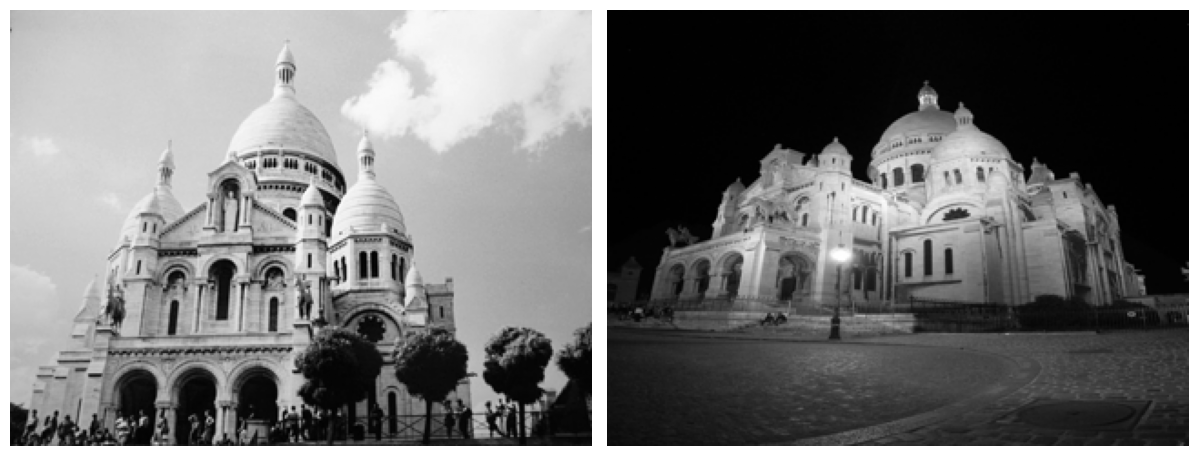

In [ ]:
# Extraction avec la V2
f0 = extract_features_refined_v2(student_refined, img_real0)
f1 = extract_features_refined_v2(student_refined, img_real1)

# Matching
with torch.no_grad():
    out = matcher({'image0': f0, 'image1': f1})

# Filtrage des matches valides
kpts0 = f0['keypoints'][0].cpu().numpy()
kpts1 = f1['keypoints'][0].cpu().numpy()
matches = out['matches0'][0].cpu().numpy()
confidence = out['matching_scores0'][0].cpu().numpy()

valid = matches > -1
mkpts0 = kpts0[valid]
mkpts1 = kpts1[matches[valid]]

print(f"🔍 Matches validés : {len(mkpts0)}")

plt.figure(figsize=(12, 6))
plot_images([img_real0[0,0].cpu(), img_real1[0,0].cpu()])
for i in range(len(mkpts0)):
    plt.plot([mkpts0[i,0], mkpts1[i,0] + 320], [mkpts0[i,1], mkpts1[i,1]], 'g-', alpha=0.5)
plt.show()

In [ ]:

original_sp_lightglue = SuperPoint(max_num_keypoints=512).eval().to(device)


def diagnostic_teacher(img):
    with torch.no_grad():
        return original_sp_lightglue({'image': img})

print(" Test du pipeline avec le modèle Original...")
feat_diag0 = original_sp_lightglue({'image': img_real0})
feat_diag1 = original_sp_lightglue({'image': img_real1})
res_diag = matcher({'image0': feat_diag0, 'image1': feat_diag1})

valid_diag = (res_diag['matches0'][0] > -1).sum().item()
print(f" Matches avec modèle Original : {valid_diag}")

if valid_diag > 0:
    print(" Le pipeline fonctionne. Le problème vient donc de la compatibilité des descripteurs de ton modèle REFINED.")
else:
    print(" Le pipeline est cassé. Il y a un problème de format d'image ou de dimensions.")

Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_v1.pth" to /root/.cache/torch/hub/checkpoints/superpoint_v1.pth


100%|██████████| 4.96M/4.96M [00:00<00:00, 187MB/s]

🔍 Test du pipeline avec le modèle Original...
✅ Matches avec modèle Original : 19
💡 Le pipeline fonctionne. Le problème vient donc de la compatibilité des descripteurs de ton modèle REFINED.
